<a href="https://colab.research.google.com/github/likhithasreeyenumula/Collab/blob/main/Irrigation_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [13]:
df = pd.read_csv("irrigation_prediction.csv")


In [15]:
X = df.drop("Irrigation_Need", axis=1)
y = df["Irrigation_Need"]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)


In [16]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns


In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric="mlogloss",
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=300,
        random_state=42
    )
}

In [20]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("\n" + "="*50)
    print(f"Model: {name}")
    print("="*50)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))


Model: Random Forest

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.48      0.65        67
           1       0.99      1.00      0.99      1173
           2       0.95      0.98      0.97       760

    accuracy                           0.97      2000
   macro avg       0.98      0.82      0.87      2000
weighted avg       0.97      0.97      0.97      2000


Confusion Matrix:

[[  32    0   35]
 [   0 1172    1]
 [   0   17  743]]

Model: XGBoost

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        67
           1       1.00      1.00      1.00      1173
           2       0.99      1.00      0.99       760

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.98      2000
weighted avg       1.00      1.00      1.00      2000


Confusion Matrix:

[[  62    0    5]
 [   0 1171    2]
 [   0    2  758]]


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [21]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

print("\n\nMODEL COMPARISON")
print("="*60)
print(results_df.sort_values(
    by="Accuracy",
    ascending=False
))



MODEL COMPARISON
           Model  Accuracy  Precision  Recall  F1-Score
1        XGBoost    0.9955   0.995523  0.9955  0.995459
0  Random Forest    0.9735   0.974053  0.9735  0.970601
4            MLP    0.9065   0.905458  0.9065  0.905602
2            SVM    0.8715   0.874707  0.8715  0.866472
3            KNN    0.7325   0.716536  0.7325  0.721752


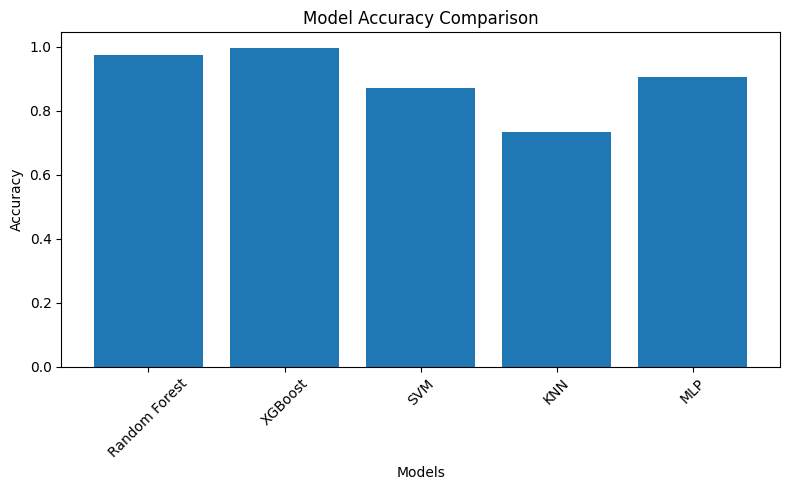

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Models')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

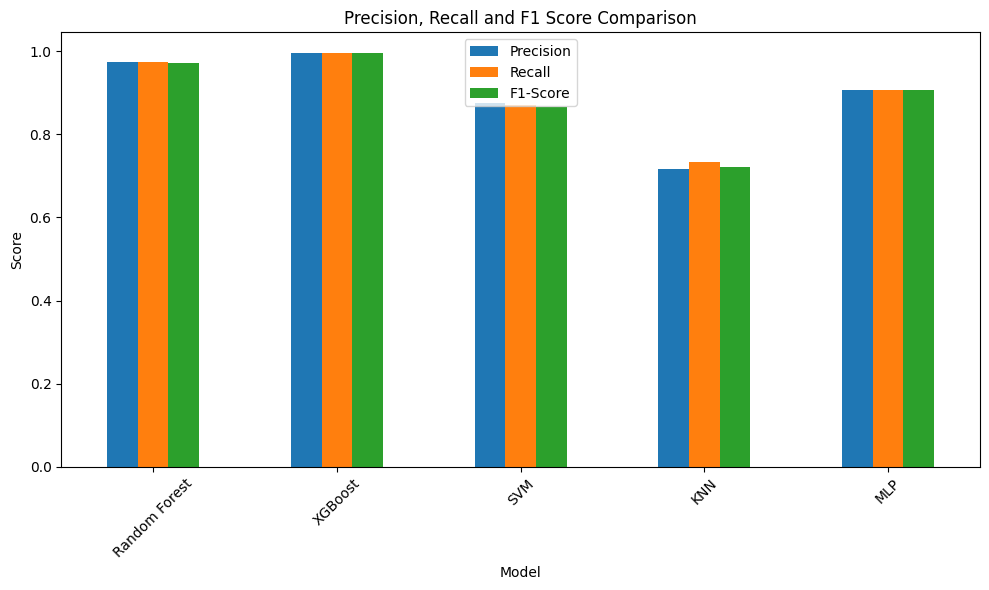

In [23]:
metrics_df = results_df.set_index('Model')[['Precision','Recall','F1-Score']]

metrics_df.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Precision, Recall and F1 Score Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

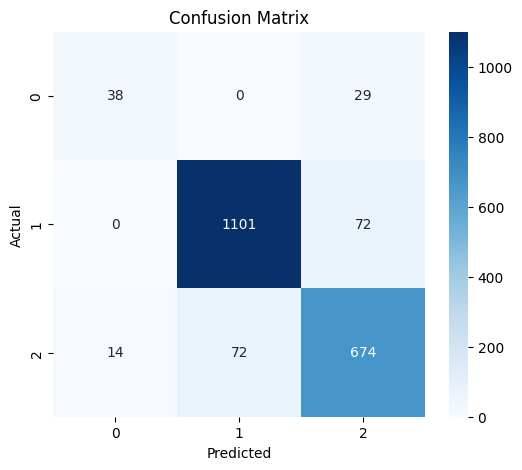

In [24]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

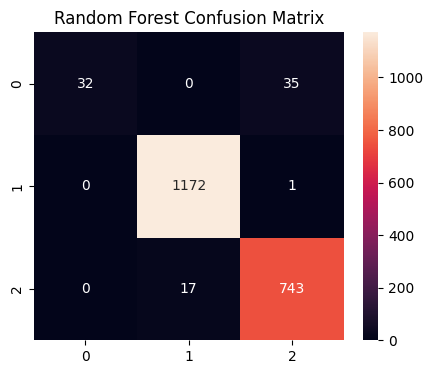

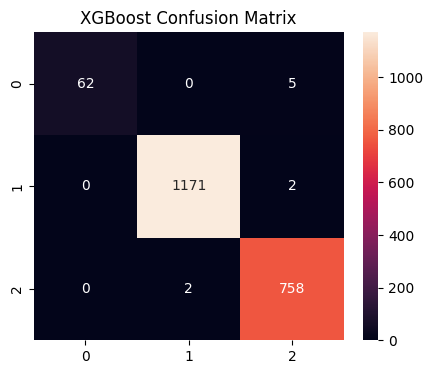

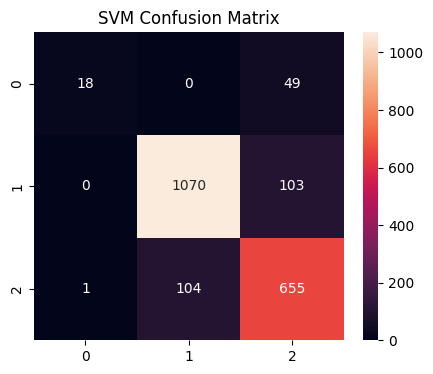

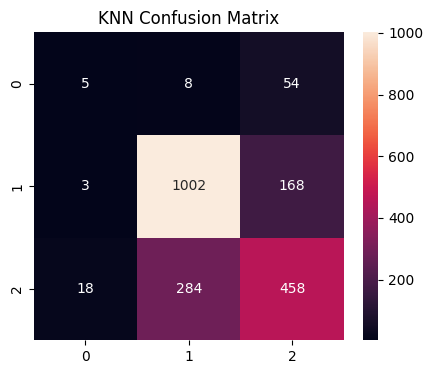

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


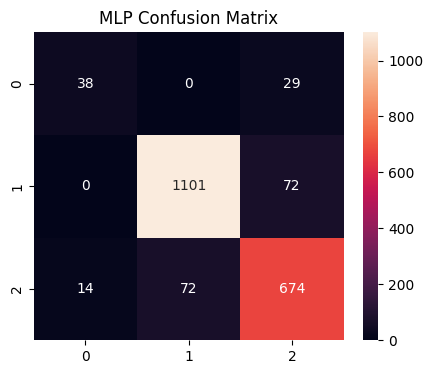

In [25]:
for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

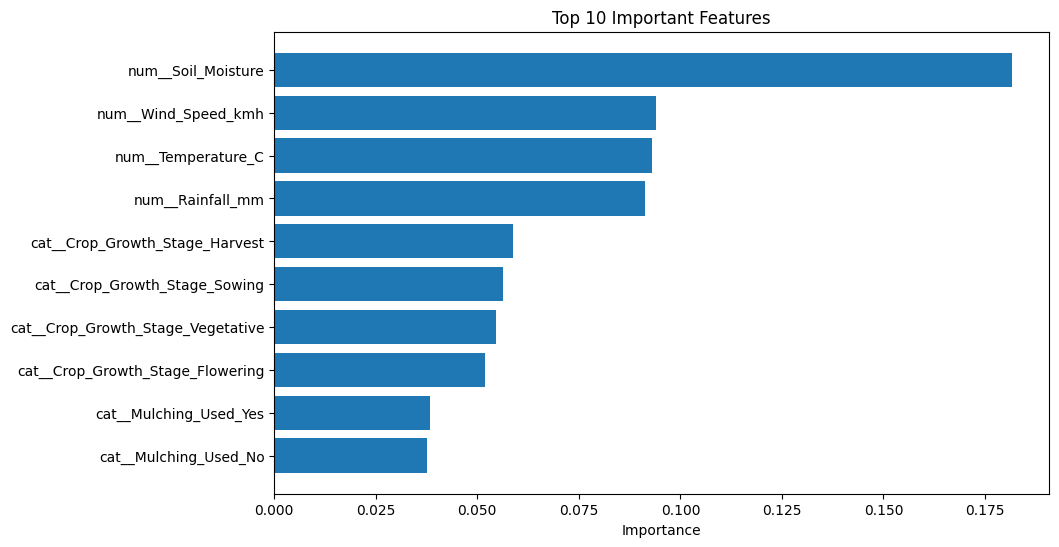

In [26]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

feature_names = rf_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

importances = rf_pipeline.named_steps[
    'classifier'
].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)
plt.title('Top 10 Important Features')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

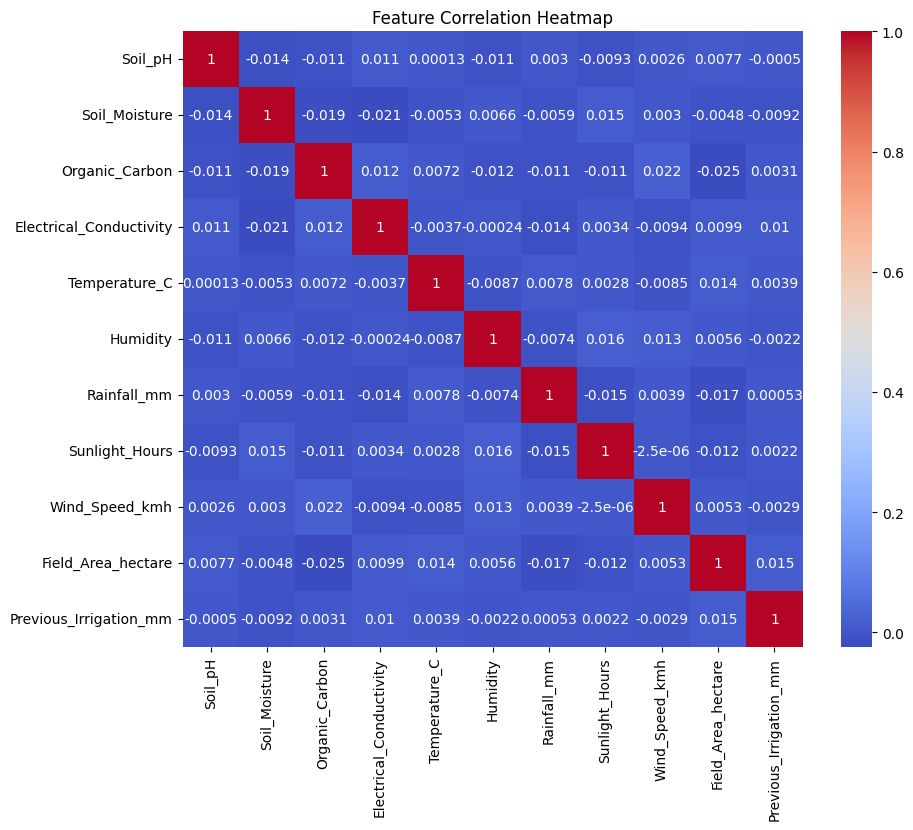

In [27]:
import seaborn as sns

numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation Heatmap')
plt.show()